In [111]:
## Importing Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [37]:
## Data Preprocessing
## Training Image Preprocessing

training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 70295 files belonging to 38 classes.


In [38]:
## Validation Image Preprocessing

validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [39]:
### Building Moedel
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [40]:
model = Sequential()

In [41]:
### Building Convolution Layer
model.add(Conv2D(filters=32 , kernel_size=3 , padding='same' , activation='relu' , input_shape=[128 , 128 , 3]))
model.add(Conv2D(filters=32 , kernel_size=3 , activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [42]:
model.add(Conv2D(filters=64 , kernel_size=3 , padding='same' , activation='relu'))
model.add(Conv2D(filters=64 , kernel_size=3 , activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [43]:
model.add(Conv2D(filters=128 , kernel_size=3 , padding='same' , activation='relu'))
model.add(Conv2D(filters=128 , kernel_size=3 , activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [44]:
model.add(Conv2D(filters=256 , kernel_size=3 , padding='same' , activation='relu'))
model.add(Conv2D(filters=256 , kernel_size=3 , activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [45]:
model.add(Conv2D(filters=512 , kernel_size=3 , padding='same' , activation='relu'))
model.add(Conv2D(filters=512 , kernel_size=3 , activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [46]:
model.add(Dropout(0.25))

In [47]:
model.add(Flatten())

In [48]:
model.add(Dense(units=1500 , activation='relu'))

In [49]:
model.add(Dropout(0.4))

In [50]:
### Output Layer
model.add(Dense(units=38 , activation='softmax'))

In [51]:
### Compiling Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
### Model Training
training_history = model.fit(x=training_set , validation_data=validation_set , epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 290s 130ms/step - accuracy: 0.5462 - loss: 1.5733 - val_accuracy: 0.8042 - val_loss: 0.6347
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 325s 148ms/step - accuracy: 0.8161 - loss: 0.6085 - val_accuracy: 0.8467 - val_loss: 0.5172
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 337s 153ms/step - accuracy: 0.8803 - loss: 0.3934 - val_accuracy: 0.9227 - val_loss: 0.2711
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 350s 159ms/step - accuracy: 0.9095 - loss: 0.3019 - val_accuracy: 0.9239 - val_loss: 0.2535
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 355s 161ms/step - accuracy: 0.9265 - loss: 0.2453 - val_accuracy: 0.9368 - val_loss: 0.2205
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 361s 164ms/step - accuracy: 0.9393 - loss: 0.2078 - val_accuracy: 0.9329 - val_loss: 0.2443
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 362s 165ms/step - accuracy: 0.9500 - loss: 0.1763 - val_accuracy: 0.9303 - val_loss: 0.3251
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 361s 164ms/step - ac

In [55]:
### Model Evaluation
train_loss , train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 56s 26ms/step - accuracy: 0.9799 - loss: 0.0753


In [56]:
print(train_loss , train_acc)

0.07529611885547638 0.9799416661262512


In [58]:
validation_loss , validation_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9509 - loss: 0.2474


In [59]:
print(validation_loss , validation_acc)

0.24742184579372406 0.9508877992630005


In [63]:
### Saving Model
model.save('my_model.h5')
model.save('my_model.keras')

In [64]:
training_history.history

{'accuracy': [0.5462408661842346,
  0.8161462545394897,
  0.8803044557571411,
  0.9095383882522583,
  0.9264954924583435,
  0.939298689365387,
  0.9500249028205872,
  0.9569955468177795,
  0.9631125926971436,
  0.9659719467163086],
 'loss': [1.5733174085617065,
  0.6084548830986023,
  0.39337223768234253,
  0.3018897771835327,
  0.24530191719532013,
  0.20777419209480286,
  0.17626354098320007,
  0.15739546716213226,
  0.13605797290802002,
  0.12621137499809265],
 'val_accuracy': [0.8042340278625488,
  0.846687912940979,
  0.9226610660552979,
  0.9239130616188049,
  0.9367744326591492,
  0.9329046010971069,
  0.930343747138977,
  0.9511154294013977,
  0.9579444527626038,
  0.9508877992630005],
 'val_loss': [0.6347330808639526,
  0.5172185301780701,
  0.2710999548435211,
  0.2535351514816284,
  0.2204950600862503,
  0.24428103864192963,
  0.32513806223869324,
  0.20614342391490936,
  0.16563424468040466,
  0.24742187559604645]}

In [65]:
### Recording History in json
import json
with open("training_hist.json" , "w") as f:
    json.dump(training_history.history , f)

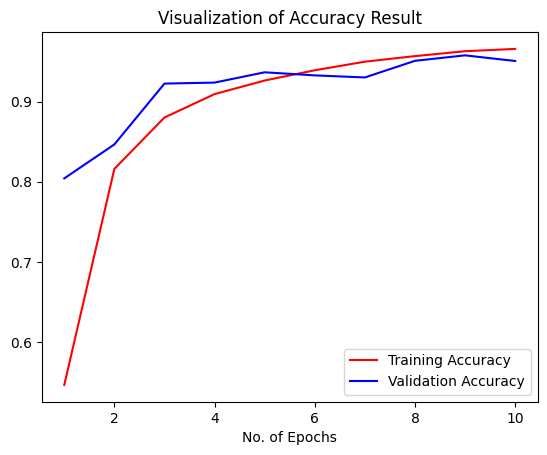

In [73]:
### Accuracy Visualization
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [75]:
### Some other metrics for model evaluation
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [76]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [79]:
y_pred = model.predict(test_set)
y_pred , y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step


(array([[1.00000000e+00, 1.18872317e-12, 1.62082409e-19, ...,
         1.78135249e-31, 1.00396844e-28, 1.51086332e-23],
        [1.00000000e+00, 4.14674892e-12, 2.63832069e-22, ...,
         2.58289324e-29, 1.54085756e-29, 2.17755674e-27],
        [1.00000000e+00, 2.90203361e-20, 2.25914693e-22, ...,
         0.00000000e+00, 6.83067718e-32, 6.66803724e-26],
        ...,
        [3.52893489e-18, 5.45986155e-27, 8.45409838e-22, ...,
         4.25233338e-22, 4.72694946e-22, 1.00000000e+00],
        [2.90748989e-17, 5.79718773e-24, 4.52072775e-18, ...,
         1.59175593e-19, 9.38844583e-21, 1.00000000e+00],
        [7.59814920e-22, 1.90643507e-26, 4.77368070e-23, ...,
         3.29698984e-27, 4.36536652e-21, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [80]:
predicted_categories = tf.argmax(y_pred , axis=1)

In [81]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [83]:
true_category = tf.concat([y for x , y in test_set] , axis=0)
true_category

2026-03-24 23:11:03.884203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [84]:
Y_true = tf.argmax(true_category , axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [86]:
from sklearn.metrics import classification_report

In [88]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.96      0.95       504
                                 Apple___Black_rot       0.99      0.94      0.96       497
                          Apple___Cedar_apple_rust       0.94      0.97      0.96       440
                                   Apple___healthy       0.98      0.87      0.92       502
                               Blueberry___healthy       0.96      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       421
                 Cherry_(including_sour)___healthy       1.00      0.95      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.97      0.85       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.91      0.

In [95]:
from sklearn.metrics import confusion_matrix

In [98]:
cm = confusion_matrix(Y_true , predicted_categories)
cm

array([[482,   2,   0, ...,   0,   0,   0],
       [  5, 465,   2, ...,   0,   0,   0],
       [  1,   0, 429, ...,   0,   1,   1],
       ...,
       [  0,   0,   0, ..., 487,   0,   0],
       [  0,   0,   0, ...,   0, 446,   0],
       [  0,   0,   0, ...,   0,   0, 479]])

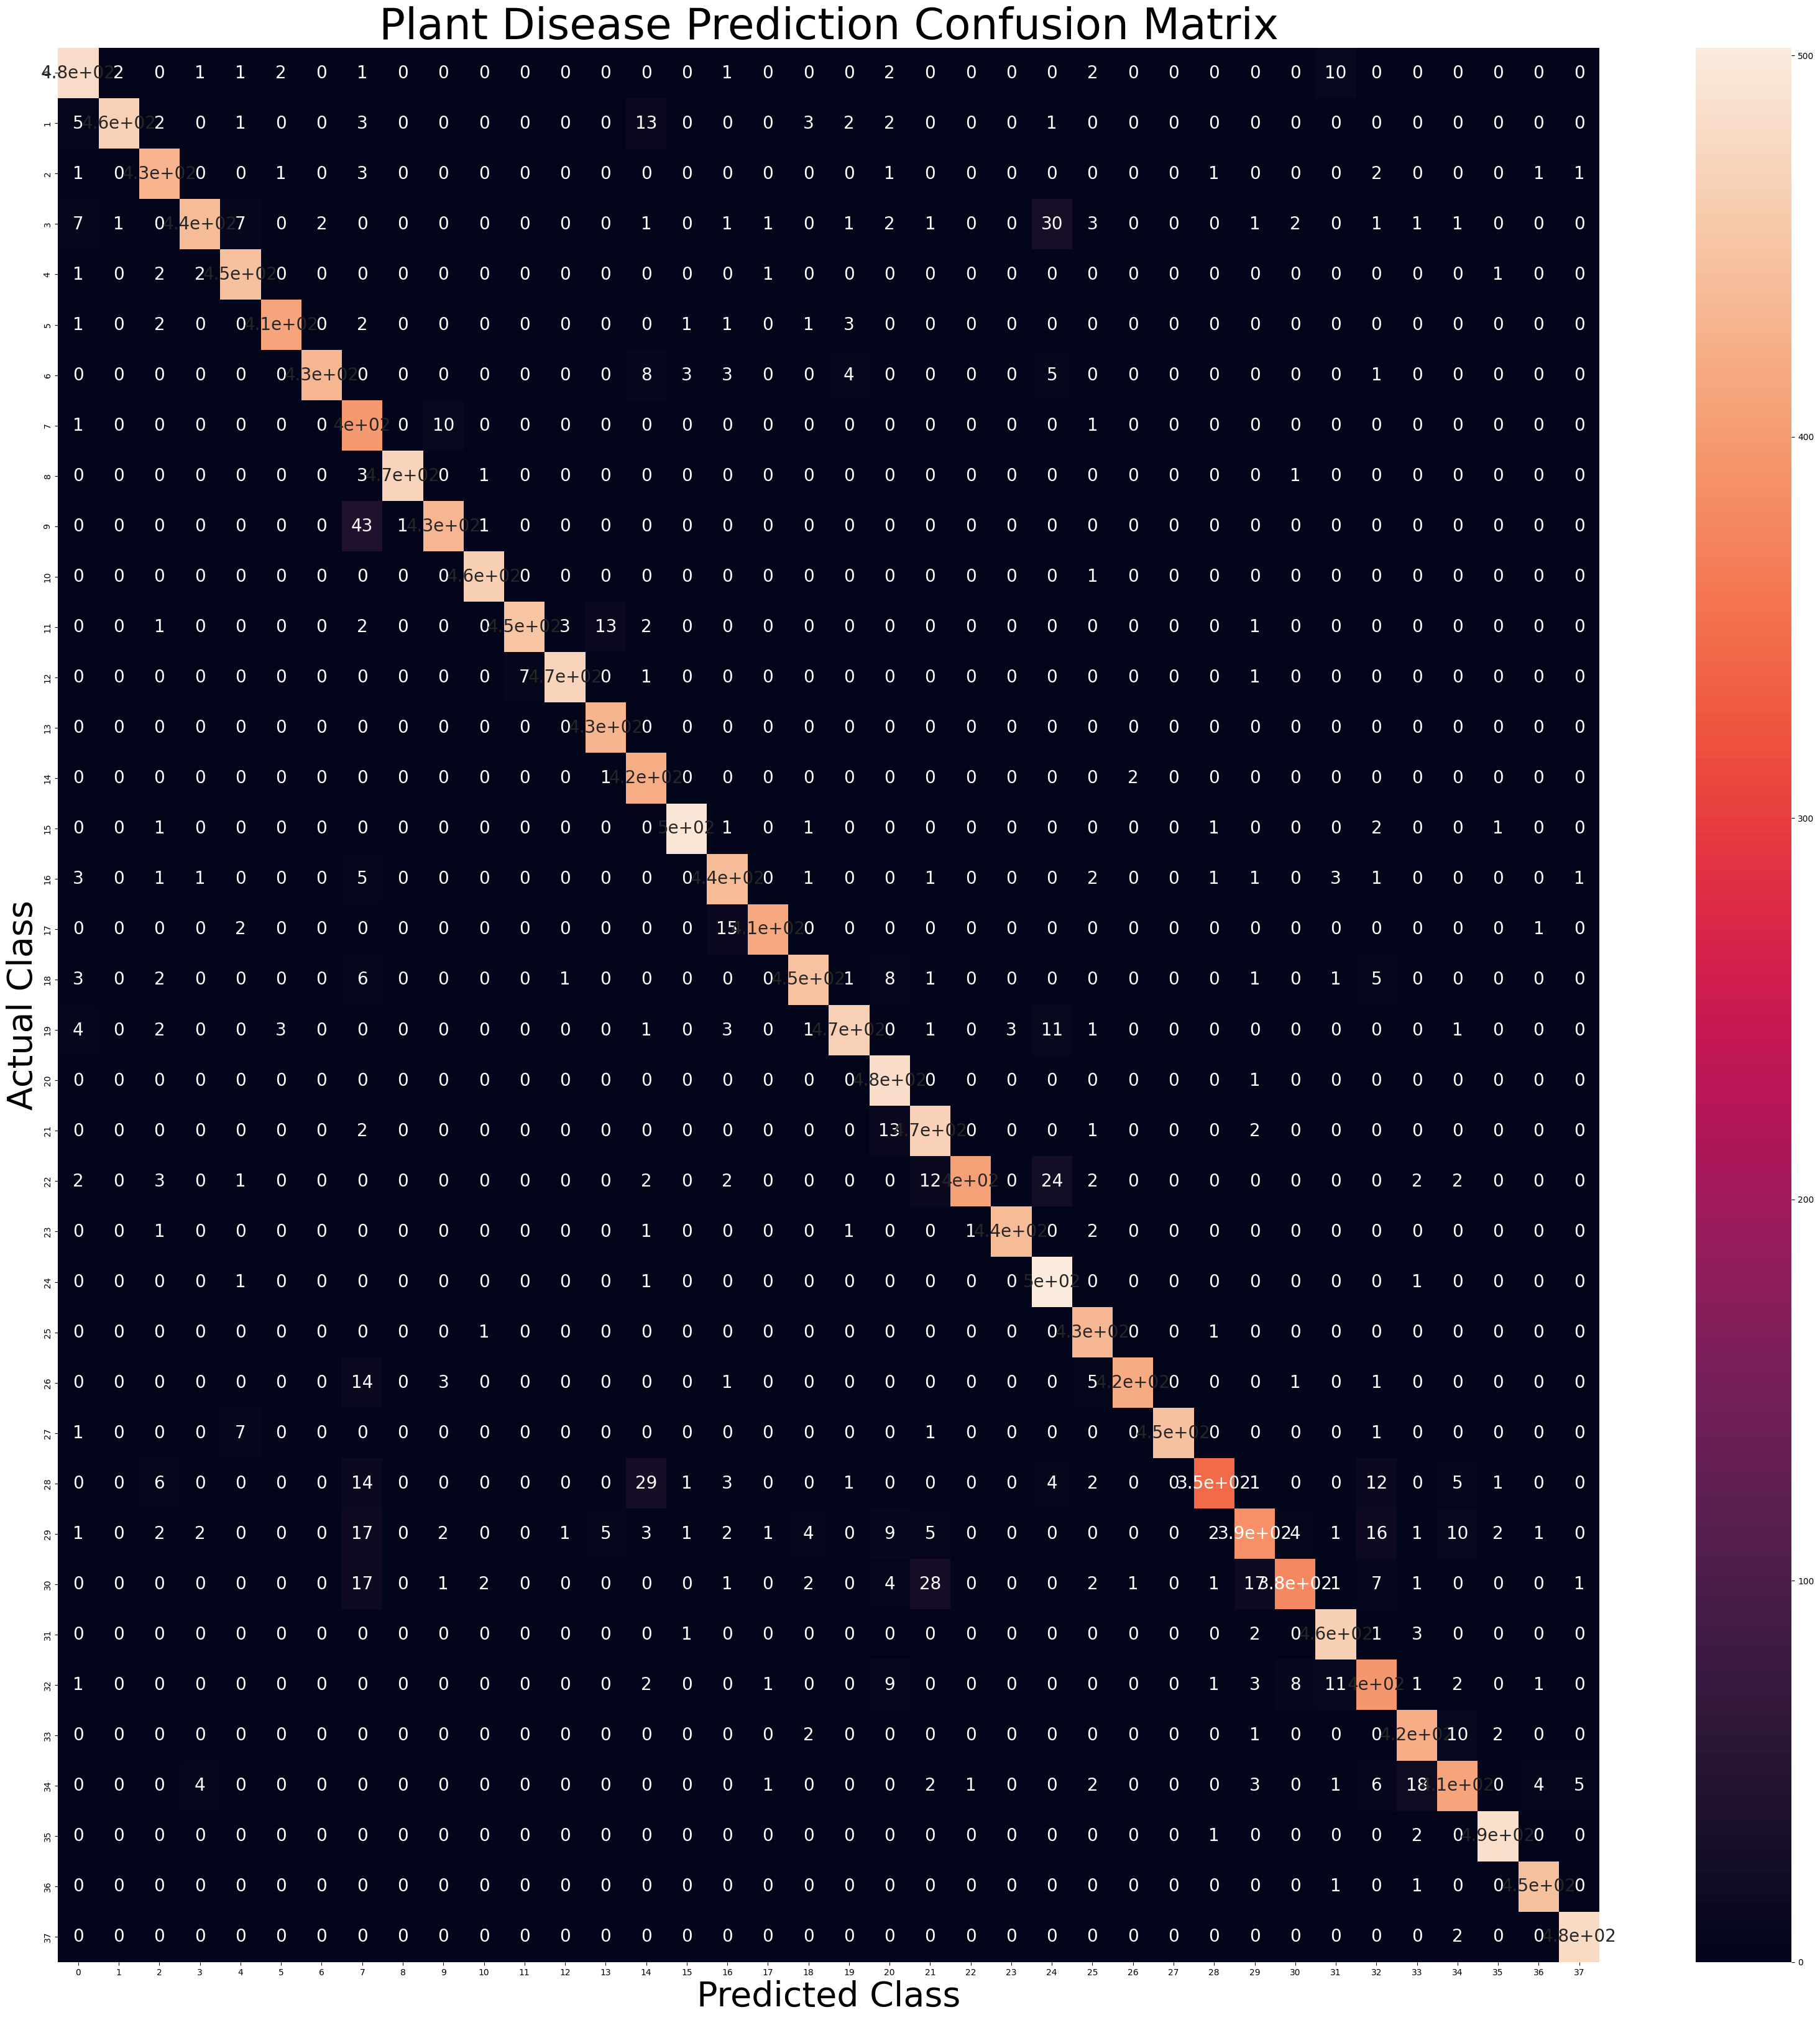

In [110]:
### Confusion Matrix Visualisation
plt.figure(figsize=(40 , 40))
sns.heatmap(cm , annot=True , annot_kws={"size": 20})
plt.xlabel("Predicted Class" , fontsize = 40)
plt.ylabel("Actual Class" , fontsize = 40)
plt.title("Plant Disease Prediction Confusion Matrix" , fontsize = 50)
plt.show()